In [1]:
import numpy as np
import pandas as pd
import anndata
import joblib
import torch
import h5py
import pyarrow as pa
import pyarrow.ipc as ipc
import json,sys, os, re

sys.path.insert(0, "/mnt/efsUCE/umap_pytorch")  #git+https://github.com/ucscBrainExplorer/umap_pytorch.git
import umap_pytorch
print(umap_pytorch.__file__)

/mnt/efsUCE/umap_pytorch/umap_pytorch/__init__.py


## transform new data to PUMAP

In [2]:
#uce_adata_file = "SstChodl_149b2c3f-ee11-47a7-984b-923570280bd7_uce_adata.h5ad"
#uce_adata_file = "Sst_3079e9b0-c6db-45c8-b998-a4555a73968e_uce_adata.h5ad"
#uce_adata_file = "Pvalb_4e374783-0152-423e-bcb6-b87cc232f64d_uce_adata.h5ad"
#uce_adata_file = "Chandelier_6929d6d1-6f81-44d7-bd35-5a580259af81_uce_adata.h5ad"
#uce_adata_file = "Sncg_390b376d-8857-4b4b-991f-0d7326938172_uce_adata.h5ad"
#uce_adata_file = "Pax6_78f40dd6-ed22-470d-8547-6fb5746c25da_uce_adata.h5ad"
#uce_adata_file = "Astro_ea95cdd5-cf7e-4d5d-a0bd-032776d32ae5_uce_adata.h5ad"
#uce_adata_file = "L23_1fc48734-35ee-4372-885c-95fd2674c75a_uce_adata.h5ad"

uce_adata_file = "tmpdata/e4ddac12-f48f-4455-8e8d-c2a48a683437-logNorm1M_uce_adata.h5ad"
uce_npy_file = None

#uce_npy_file = "UCE_npy_obs/e4ddac12-f48f-4455-8e8d-c2a48a683437_uce.npy"
#obs_file = "UCE_npy_obs/e4ddac12-f48f-4455-8e8d-c2a48a683437_obs.tsv"
# uce_adata_file = None

config_path = "combined_UCE_5neuro/transform_e119.json"

In [3]:
base = os.path.basename(config_path)        # e.g. 'pytorch_e5.pkl'
stem, _ = os.path.splitext(base)                 # ('pytorch_e5', '.pkl')

# extract iteration, the number after 'e'
match = re.search(r'e(\d+)', stem)
if match:
    iteration = int(match.group(1))
    print(iteration)  # e.g. 5
else:
    iteration = None
    print("Error: expect model name with xxx_e{num}.pkl")
    sys.exit(1)

119


In [4]:
# Read JSON file
with open(config_path, "r") as f:
    config = json.load(f)

# Access fields
pca_model_file = config["pca_model_file"]
pumap_model_file = config["pumap_model_file"]
swap_xy_matrix = np.array(config["swap_xy_matrix"])  # convert to NumPy array

In [5]:
# read pc model back, pumap model back
ipca = joblib.load(pca_model_file)
pumap = umap_pytorch.load_pumap(pumap_model_file)

Loading PUMAP object from pickled file.


In [6]:
if uce_npy_file:
    uce = np.load(uce_npy_file)
    obs = pd.read_csv(obs_file, sep='\t')
    uce.shape, obs.shape
elif uce_adata_file:
    # read uce result back
    adata = anndata.read_h5ad(uce_adata_file)
    uce = adata.obsm["X_uce"]
    obs = adata.obs
    uce.shape, obs.shape

In [7]:
# transform
X_pca = ipca.transform(uce)
X_pca.shape
X_pca = X_pca.astype(np.float32)

data_tensor = torch.from_numpy(X_pca)
X_umap_pytorch = pumap.transform(data_tensor)
X_umap_pytorch.shape

X_swapped = X_umap_pytorch @ swap_xy_matrix

Reducing array of shape torch.Size([129495, 50]) to (129495, 2)


In [8]:
# Convert to Arrow Table
cell_type_col = pa.array(obs["cell_type"].astype("category"))

table = pa.table({
    "x": X_swapped[:, 0],
    "y": X_swapped[:, 1],
    "cell_type":cell_type_col
})
# write to Arrow file
dirname = os.path.dirname(config_path)
# Remove the suffix regardless of whether it's _uce_adata.h5ad or _uce.npy
if uce_adata_file:
    base = re.sub(r"_uce_adata.h5ad$", "", uce_adata_file.split("/")[-1])
elif uce_npy_file:
    base = re.sub(r"_uce.npy)$", "", uce_adata_file.split("/")[-1])

output_path = f"{dirname}/{base}_e{iteration}.arrow"
with pa.OSFile(output_path, "wb") as sink:
    with ipc.new_file(sink, table.schema) as writer:
        writer.write_table(table)
print("Saving to", output_path)

Saving to combined_UCE_5neuro/e4ddac12-f48f-4455-8e8d-c2a48a683437-logNorm1M_e119.arrow


In [9]:
table

pyarrow.Table
x: double
y: double
cell_type: dictionary<values=string, indices=int8, ordered=0>
----
x: [[-15.584724426269531,-15.744352340698242,-15.564228057861328,-15.497407913208008,-15.832487106323242,...,-27.112354278564453,-26.63636589050293,-27.257089614868164,-27.004915237426758,-26.972909927368164]]
y: [[-19.35573959350586,-19.56781578063965,-19.59007453918457,-19.668615341186523,-20.27571678161621,...,-20.446271896362305,-19.877267837524414,-21.46723175048828,-19.98206901550293,-20.669208526611328]]
cell_type: [  -- dictionary:
["lamp5 GABAergic cortical interneuron","sncg GABAergic cortical interneuron","VIP GABAergic cortical interneuron","caudal ganglionic eminence derived cortical interneuron"]  -- indices:
[0,0,0,0,0,...,2,2,2,2,2]]

In [ ]:
sys.exit()

## reference data PUMAP

In [17]:
# Load the reference PCA data
with h5py.File(ref_pca_file, "r") as f:
    ref_pca = f["pca"][:]
print(ref_pca.shape)

(6863203, 50)


In [18]:
data_tensor = torch.from_numpy(ref_pca)
data_tensor, data_tensor.shape, data_tensor.dtype

(tensor([[-1.3789e-01, -5.0647e-02, -2.4483e-01,  ..., -3.9867e-02,
           1.9136e-02, -3.7529e-02],
         [-6.4935e-01, -5.0485e-02,  1.9319e-01,  ...,  3.2615e-04,
           6.3329e-03, -2.3519e-02],
         [-2.1407e-01, -3.1015e-02, -2.7783e-01,  ...,  2.2908e-02,
           2.8329e-02, -3.7532e-02],
         ...,
         [ 3.3838e-01, -2.1018e-01,  2.9850e-01,  ...,  1.9307e-02,
           1.0142e-02,  7.0055e-03],
         [-1.9930e-01, -9.1405e-02, -4.8137e-01,  ...,  5.9510e-02,
           3.4569e-02, -6.5756e-02],
         [ 1.0927e-01, -2.1275e-01, -1.9878e-01,  ..., -1.2639e-02,
           2.0938e-03,  2.3114e-02]]),
 torch.Size([6863203, 50]),
 torch.float32)

In [19]:
# batch transform
batch_size = 1_000_000
n_samples = data_tensor.shape[0]
embedding_dim = 2   # since n_components=2

# Preallocate result array
ref_umap_pytorch = np.zeros((n_samples, embedding_dim), dtype=np.float32)

# Loop over batches
for start in range(0, n_samples, batch_size):
    end = min(start + batch_size, n_samples)
    batch = data_tensor[start:end]

    emb = pumap.transform(batch) ### transformation

    ref_umap_pytorch[start:end] = emb

print("✅ Done. Final embedding shape:", ref_umap_pytorch.shape)

Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Reducing array of shape torch.Size([863203, 50]) to (863203, 2)
✅ Done. Final embedding shape: (6863203, 2)


## Plot

In [20]:
X_swapped.shape, ref_umap_pytorch.shape

((129495, 2), (6863203, 2))

In [21]:
subset_indices = np.random.choice(ref_umap_pytorch.shape[0], 100_000, replace=False)
ref_umap_pytorch_subset = ref_umap_pytorch[subset_indices, :]

In [22]:
combined_umap = np.vstack([X_umap_pytorch, ref_umap_pytorch_subset])
labels = np.array(['query'] * X_umap_pytorch.shape[0] + ['reference'] * ref_umap_pytorch_subset.shape[0])

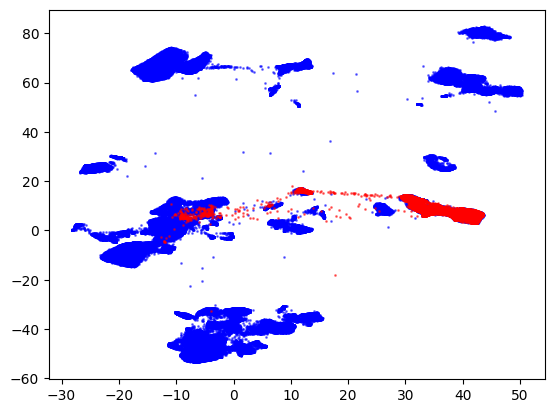

In [23]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

for label, color,size in zip(['reference', 'query' ], ['blue', 'red'], [0.1, 1]):
    mask = labels == label
    plt.scatter(combined_umap[mask, 0], combined_umap[mask, 1], 
                c=color, label=label, alpha=0.5, s=1)
plt.show()